<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 60px;
    font-weight: bold;
    text-align: center;
    color: #ff4b5c;
    background-color: #1e1e1e;
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 6px 12px rgba(0,0,0,0.3);
">
📧 Spam Email Detection 🚫📨
</h1>

<div align="center">
    <img src="https://blogcdn.gmass.co/blog/wp-content/uploads/2021/01/spamfolder-feat-redo-tinified.png" width="800">
</div>
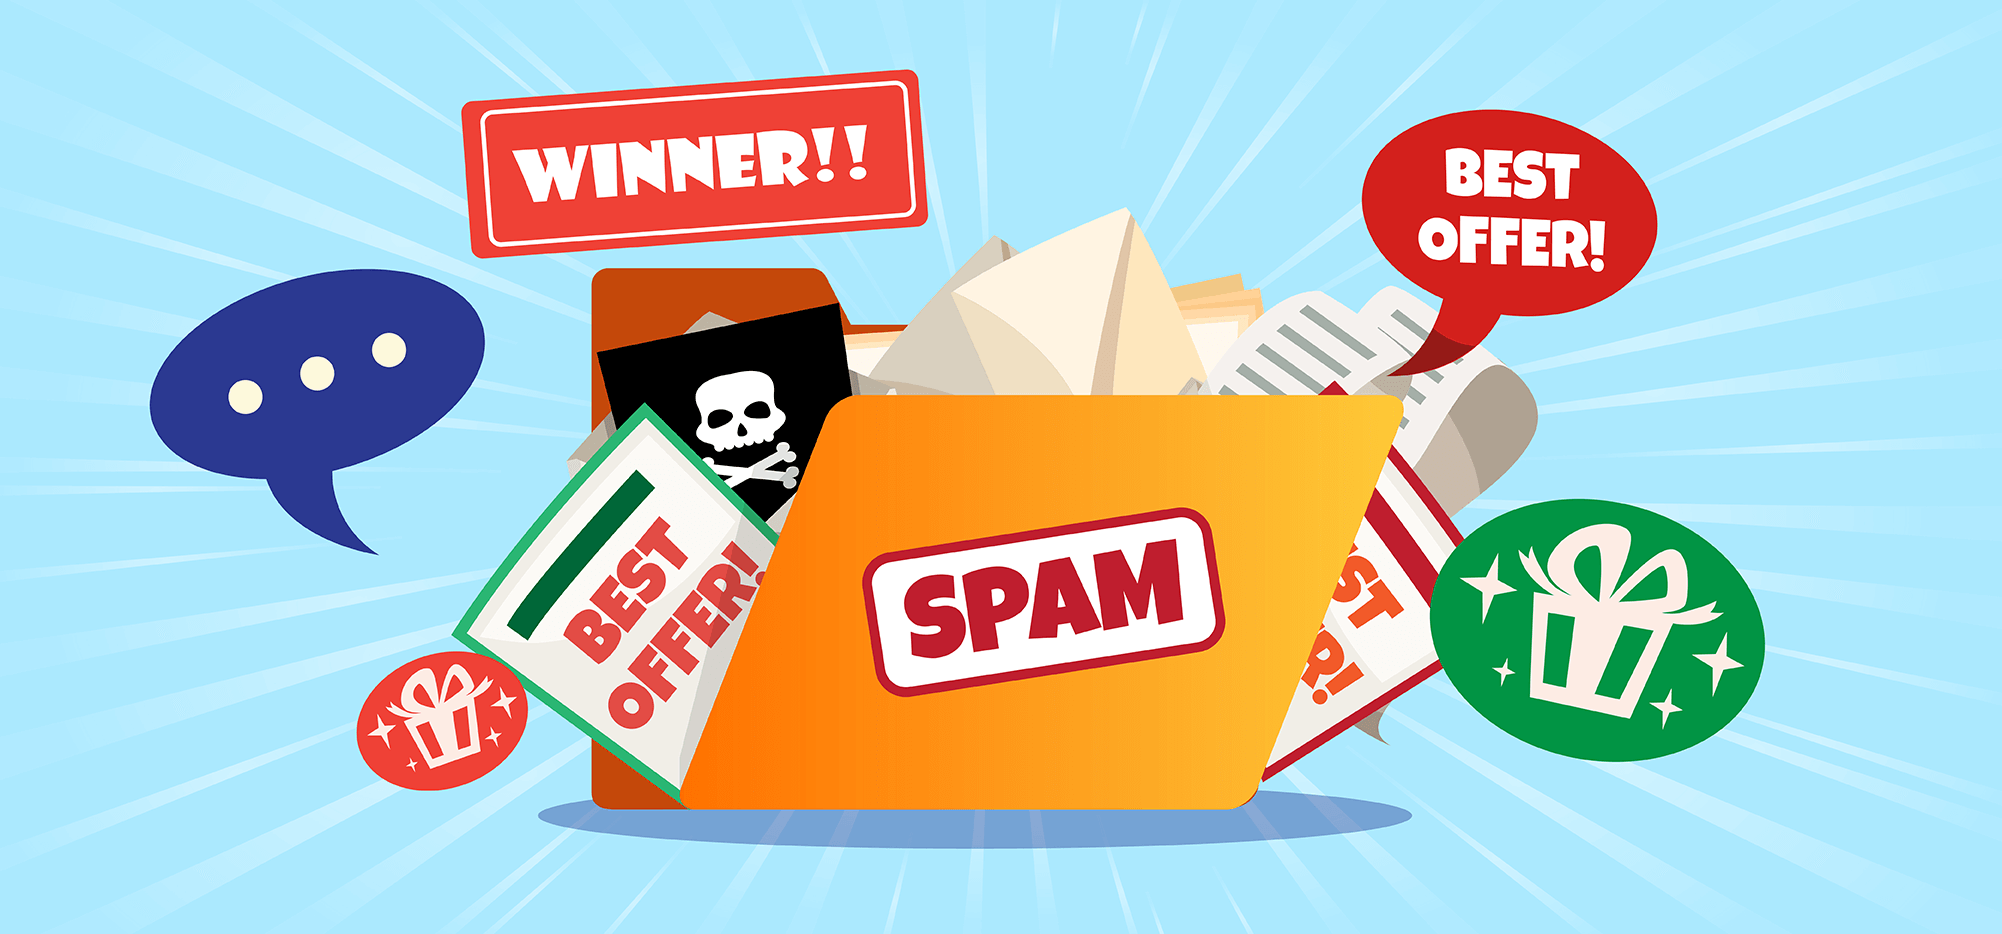

<h3 align="center" style="color: gray;">
Built using Logistic Regression & TF-IDF Vectorization
</h3>

<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 60px;
    font-weight: bold;
    text-align: center;
    color: #black;
">
========= Meta Data =========
</h1>
<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 30px;
    font-weight: bold;
    text-align: left;
    color: red;
">
--- Overview ---
</h1>

The **Spam Email Dataset** contains information about email messages labeled as `spam` or `ham` (non-spam). It consists of 100 entries with 2 columns:

- **text:** The content of the email message.  
- **label:** The target variable indicating whether the email is `spam` (unwanted/potentially malicious) or `ham` (legitimate).

</h1>
<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 30px;
    font-weight: bold;
    text-align: left;
    color: red;
">
--- Summary Statistics ---
</h1>

- The dataset contains 100 entries.  
- The columns are:  
  - `text` → string (email content)  
  - `label` → categorical (`spam` or `ham`)  
- Approximately 40% of the emails are labeled as `spam` and 60% as `ham`.  
- No missing values exist in the dataset.

</h1>
<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 30px;
    font-weight: bold;
    text-align: left;
    color: red;
">
--- Usage ---
</h1>

This dataset can be utilized for various tasks, including:

- **Exploratory Data Analysis (EDA):** Examine the distribution of spam vs. ham emails and analyze common spam keywords.  
- **Text Preprocessing:** Apply techniques such as tokenization, lowercasing, stopword removal, and stemming/lemmatization to prepare the text for modeling.  
- **Predictive Modeling:** Build machine learning models, such as **Logistic Regression**, to classify emails as spam or ham using text vectorization methods like **TF-IDF**.  
- **Model Evaluation:** Assess model performance using metrics such as accuracy, precision, recall, and F1-score.  
- **Feature Engineering:** Explore additional features like email length, punctuation frequency, or special character counts.

<h1 style="
    font-family: 'Brush Script MT', cursive;
    font-size: 30px;
    font-weight: bold;
    text-align: left;
    color: red;
">
--- Conclusion ---
</h1>

The Spam Email Dataset provides a compact and illustrative example for learning email classification using machine learning. By leveraging this dataset, one can explore text preprocessing, vectorization, and predictive modeling techniques, which are fundamental for building automated spam detection systems.
"""))

<p style="font-family: 'Brush Script MT', cursive; font-size: 50px; font-weight: bold; text-align: center; color: #ff4b5c; background-color: #212529; padding: 10px 20px 10px 10px; border: 2px solid #343a40; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">~~~~ Import Dataset and Modules ~~~~</p>


In [1]:
import pandas as pd

import matplotlib.pyplot as plt       
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('spam_email_dataset.csv')
df

,text,label
0,"Hi, can we reschedule our meeting?",ham
1,Please find attached the project report.,ham
2,URGENT! Your account has been compromised.,spam
3,Reminder: Your electricity bill is due tomorrow.,ham
4,"Hi, can we reschedule our meeting?",ham
...,...,...
95,Limited time offer! Buy now!,spam
96,Reminder: Your electricity bill is due tomorrow.,ham
97,Free vacation to the Bahamas. Reply now!,spam
98,"Hey, are we still on for lunch today?",ham


<p style="font-family: 'Brush Script MT', cursive; font-size: 50px; font-weight: bold; text-align: center; color: #ff4b5c; background-color: #212529; padding: 10px 20px 10px 10px; border: 2px solid #343a40; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">~~~~ Data Analysis, Cleaning and Visualization ~~~~</p>

In [2]:
# 1. First 5 rows
print("----- First 5 rows -----")
print(df.head())

print("\n")

# 2. Last 5 rows
print("----- Last 5 rows -----")
print(df.tail())

print("\n")

# 3. Check for null values
print("----- Null values in each column -----")
print(df.isnull().sum())

print("\n")

# 4. Data types of each column
print("----- Data types -----")
print(df.dtypes)

print("\n")

# 5. Column names
print("----- Column Names -----")
print(df.columns.tolist())

print("\n")

# 2. Unique values in 'label' column
print("----- Unique Labels -----")
print(df['label'].unique())

----- First 5 rows -----
                                               text label
0                Hi, can we reschedule our meeting?   ham
1          Please find attached the project report.   ham
2        URGENT! Your account has been compromised.  spam
3  Reminder: Your electricity bill is due tomorrow.   ham
4                Hi, can we reschedule our meeting?   ham


----- Last 5 rows -----
                                                text label
95                      Limited time offer! Buy now!  spam
96  Reminder: Your electricity bill is due tomorrow.   ham
97          Free vacation to the Bahamas. Reply now!  spam
98             Hey, are we still on for lunch today?   ham
99             Let's catch up over coffee next week.   ham


----- Null values in each column -----
text     0
label    0
dtype: int64


----- Data types -----
text     object
label    object
dtype: object


----- Column Names -----
['text', 'label']


----- Unique Labels -----
['ham' 'spam']


/var/folders/1r/0yg90q853l31p7xmrnsgc61h0000gn/T/ipykernel_23319/2549701399.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['blue','red'])


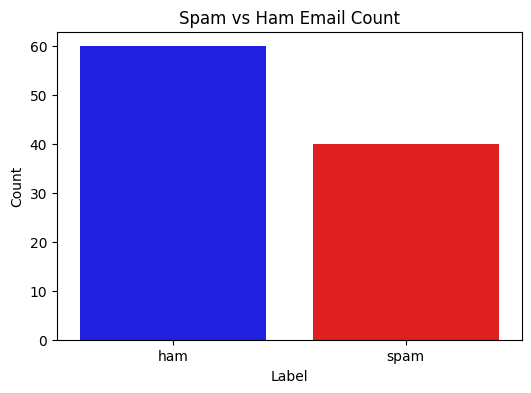

In [3]:
df['text'] = df['text'].str.lower()

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['blue','red'])
plt.title("Spam vs Ham Email Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

<p style="font-family: 'Brush Script MT', cursive; font-size: 50px; font-weight: bold; text-align: center; color: #ff4b5c; background-color: #212529; padding: 10px 20px 10px 10px; border: 2px solid #343a40; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">~~~~ Modelling | Spam Email Detection ~~~~</p>

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['label']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
y_pred = model.predict(X_test)

In [7]:
# 1. Model Accuracy
print("----- Model Accuracy -----")
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)   

print("\n")

# 2. Detailed Classification Report
print("----- Classification Report -----")
report = classification_report(y_test, y_pred)
print(report)

----- Model Accuracy -----
1.0


----- Classification Report -----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



<p style="font-family: 'Brush Script MT', cursive; font-size: 50px; font-weight: bold; text-align: center; color: #ff4b5c; background-color: #212529; padding: 10px 20px 10px 10px; border: 2px solid #343a40; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">~~~~ Testing With New Email ~~~~</p>

In [8]:
new_email = ["Congratulations! You won a free iPhone. Click here to claim it!", "Small progress is still progress — don’t give up!"]
for i in new_email:
    new_email_tfidf = vectorizer.transform([i])
    
    prediction = model.predict(new_email_tfidf)
        
    if prediction[0] == 1:
        print("⚠️ The email is SPAM!")
    else:
        print("✅ The email is HAM (not spam).")

⚠️ The email is SPAM!
✅ The email is HAM (not spam).


<div style="text-align: center;">
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExdDl1N2pybm1tOWJxbTIzcjUya3pseGY2aHA5bmJ4cmM2MTZ3a3poYSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/6riEABBXLBsfplIFMw/giphy.gif" 
         alt="Cool GIF" 
         width="270">
    <p style="font-family: 'Brush Script MT', cursive; margin-top: 10px; color: #ff69b4; font-weight: bold; font-size: 24px;"><b>~~~Akisa Vujel~~~</b></p>
</div>